# Brain Tumor MRI Classification using PyTorch

---
#### DISCLAIMER: THIS IS NOT MEDICAL ADVICE, DO NOT SELF DIAGNOSE

## Imports and loading data

In [1]:
import torch
from torch import nn, optim
from torch.nn import Flatten
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# use gpu if it's available if not cpu which is much slower
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Image transformations
Certain transformations are needed before using an image, e.g resize, changing to tensor and normalizing

In [2]:
# Every image will go through this transformation pipeline
pic_trans = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [3]:
train_dl = DataLoader(
    datasets.ImageFolder('data/Training', pic_trans),
    batch_size=32,
    shuffle=True,
    num_workers=4, # speeds up loading data
    pin_memory=True
)

test_dl = DataLoader(
    datasets.ImageFolder('data/Testing', pic_trans),
    batch_size=32,
    shuffle=False, # there is no need to shuffle, as this is just for evaluation
    num_workers=4, # speeds up loading data
    pin_memory=True
)

## Define model

In [4]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 4) # final layer, which takes 256 as input and 4 as output (4 classes
).to(device)

In [5]:
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

## Training loop

In [6]:
for epoch in range(25):
    running_loss = 0

    for x, y in train_dl:
        opt.zero_grad()

        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()

        running_loss += loss.item()
        opt.step()

    print(f'Epoch {epoch+1}: Loss was {running_loss}')

Epoch 1: Loss was 129.99363136291504
Epoch 2: Loss was 74.39930345118046
Epoch 3: Loss was 52.97336833924055
Epoch 4: Loss was 38.2747937887907
Epoch 5: Loss was 27.086255567148328
Epoch 6: Loss was 21.961963262408972
Epoch 7: Loss was 15.93149384111166
Epoch 8: Loss was 13.549519814085215
Epoch 9: Loss was 10.021197996567935
Epoch 10: Loss was 8.30900313751772
Epoch 11: Loss was 7.571183861640748
Epoch 12: Loss was 7.868479527794989
Epoch 13: Loss was 3.049659520474961
Epoch 14: Loss was 6.922841967258137
Epoch 15: Loss was 4.214330400485778
Epoch 16: Loss was 2.9432364166132174
Epoch 17: Loss was 4.541297887742985
Epoch 18: Loss was 5.205281868311431
Epoch 19: Loss was 5.861120239744196
Epoch 20: Loss was 3.098511636508192
Epoch 21: Loss was 2.2079385127499336
Epoch 22: Loss was 4.775225088331354
Epoch 23: Loss was 5.699621674488299
Epoch 24: Loss was 4.832781342975068
Epoch 25: Loss was 4.348923476910386


In [7]:
model.eval()
test_loss, correct = 0.0, 0
with torch.no_grad():
    for x, y in test_dl:
        y, y = x.to(device), y.to(device)

        logits = model(x)
        test_loss = loss_fn(logits, y).item() * y.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).float().sum().item()

test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct / len(test_dl.dataset)

print(f'Test set: Average loss: {test_loss}, Accuracy: {accuracy}')

Test set: Average loss: 0.0011493895202875138, Accuracy: 88.6875


Decent with room for improvement ;))

## Visualising image

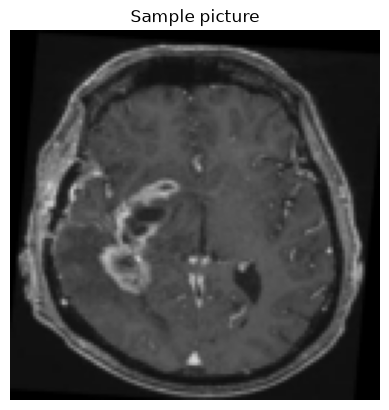

Predicted: notumor
Actual: glioma


In [8]:
import random
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

unnorm = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample picture')
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(dim=1).item()

class_names = test_dl.dataset.classes
print(f'Predicted: {class_names[pred]}')
print(f'Actual: {class_names[label]}')

## Conclusion
Model is decent but there is room for improvement. Hyperparameter tuning, trying different architectures and optimisers, learning rates, model checkpointing.

## Model tuning

In [9]:
from torch.utils.data import random_split

IMG = 256      # image size (was 128)
EPOCHS = 8     # epochs per optimiser/learning rate combination

# resize, convert to tensor and scale pixel values to [-1, 1]
pic_trans = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# load the training folder and hold out 15% as a validation set for tuning
# 85/15 train/validation split, test set kept for the very end
full = datasets.ImageFolder('data/Training', pic_trans)
n_val = int(0.15 * len(full))
train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=torch.Generator().manual_seed(42))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_dl = DataLoader(val_ds, batch_size=32, num_workers=4)
test_dl = DataLoader(datasets.ImageFolder('data/Testing', pic_trans), batch_size=32, num_workers=4)

Adam, lr=0.01: best val acc 0.2667
Adam, lr=0.001: best val acc 0.9202
Adam, lr=0.0001: best val acc 0.8881
SGD, lr=0.01: best val acc 0.9238
SGD, lr=0.001: best val acc 0.8476
SGD, lr=0.0001: best val acc 0.7012
RMSprop, lr=0.01: best val acc 0.8262
RMSprop, lr=0.001: best val acc 0.9155
RMSprop, lr=0.0001: best val acc 0.9060
lr           0.0001    0.0010    0.0100
optimiser                              
Adam       0.888095  0.920238  0.266667
RMSprop    0.905952  0.915476  0.826190
SGD        0.701190  0.847619  0.923810
Best: SGD, lr=0.01, epoch 7 | test acc 0.8619


In [10]:
# builds a fresh, untrained copy of the CNN, so every run starts from scratch
def make_model():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(128 * (IMG // 8) ** 2, 256), nn.ReLU(), nn.Dropout(0.5),  # 3 poolings: 256 -> 32
        nn.Linear(256, 4)
    ).to(device)

In [11]:
# returns the share of correctly classified images in a data loader
def accuracy(model, dl):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
    return correct / len(dl.dataset)

optimisers = {
    'Adam': lambda p, lr: optim.Adam(p, lr=lr),
    'SGD': lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9),
    'RMSprop': lambda p, lr: optim.RMSprop(p, lr=lr),
}

learning_rates = [1e-2, 1e-3, 1e-4]
loss_fn = nn.CrossEntropyLoss()
results, best_acc = [], 0

## Final training
Grid search over optimisers (`Adam`, `SGD`, `RMSprop`) and learning rates `[1e-2, 1e-3, 1e-4]` showed `SGD` (`lr=1e-4`, `momentum=0.9`) improving validation accuracy across the sweep (0.701190 -> 0.847619 -> 0.923810), making it the best optimiser overall. Training the winning configuration for 25 epochs on the full training set below.

In [17]:
model = make_model()
opt = optimisers['SGD'](model.parameters(), 1e-4)

best_val_acc = 0.0
for epoch in range(25):
    model.train()
    running_loss = 0.0

    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()

        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()

        running_loss += loss.item()

    val_acc = accuracy(model, val_dl)
    print(f'Epoch {epoch+1}: loss={running_loss:.4f}, val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')

print(f'Best validation accuracy: {best_val_acc:.4f}')


Epoch 1: loss=204.3791, val_acc=0.5060
Epoch 2: loss=197.9123, val_acc=0.6155
Epoch 3: loss=187.0224, val_acc=0.5940
Epoch 4: loss=172.1090, val_acc=0.6786
Epoch 5: loss=156.9216, val_acc=0.6810
Epoch 6: loss=143.8051, val_acc=0.6952
Epoch 7: loss=131.5148, val_acc=0.6702
Epoch 8: loss=121.6619, val_acc=0.7000
Epoch 9: loss=112.8211, val_acc=0.6940
Epoch 10: loss=107.1802, val_acc=0.7119
Epoch 11: loss=100.7867, val_acc=0.7226
Epoch 12: loss=95.1128, val_acc=0.7452
Epoch 13: loss=93.6770, val_acc=0.7595
Epoch 14: loss=88.9669, val_acc=0.7845
Epoch 15: loss=86.3959, val_acc=0.7833
Epoch 16: loss=82.7160, val_acc=0.7464
Epoch 17: loss=81.7359, val_acc=0.7905
Epoch 18: loss=78.6695, val_acc=0.7881
Epoch 19: loss=76.7904, val_acc=0.7798
Epoch 20: loss=75.4568, val_acc=0.7786
Epoch 21: loss=73.3462, val_acc=0.7905
Epoch 22: loss=72.7191, val_acc=0.8036
Epoch 23: loss=71.3926, val_acc=0.8095
Epoch 24: loss=69.4389, val_acc=0.7679
Epoch 25: loss=67.2692, val_acc=0.7964
Best validation accurac

In [18]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
test_acc = accuracy(model, test_dl)
print(f'Test set accuracy: {test_acc:.4f}')


Test set accuracy: 0.7350
